# Análise Exploratória — Futebol Internacional (1872–2026)

**Tema:** Previsão de resultados de partidas internacionais de futebol (vitória do
mandante / empate / vitória do visitante) a partir do histórico de desempenho das
seleções.

**Dataset:** [International football results from 1872 to 2026](https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017)
(Kaggle / martj42, dados publicados sob licença CC0 1.0 — domínio público).
Mantido a partir do repositório [martj42/international_results](https://github.com/martj42/international_results)
no GitHub.

Este notebook cobre a etapa de **Análise Exploratória de Dados (EDA)**: entender
a estrutura da base, formular hipóteses iniciais e validá-las com estatísticas e
gráficos, antes da etapa de modelagem (ver `notebooks/02_modeling.ipynb` e
`src/modeling.py`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline

import sys
sys.path.insert(0, "..")
from src.data_prep import load_raw_results, clean_results, categorize_tournament

raw = load_raw_results()
df = clean_results(raw)
df["tournament_category"] = df["tournament"].apply(categorize_tournament)
df.shape


[clean_results] Removidas 52 partidas futuras/sem placar (ex.: jogos da Copa do Mundo 2026 ainda nao disputados).


(49425, 14)

## 1. Visão geral do dataset

A base bruta (`results.csv`) traz uma linha por partida internacional masculina
disputada desde 1872, com data, seleções, placar, tipo de competição, cidade/país
da partida e se foi em campo neutro. O arquivo é atualizado continuamente — por
isso o título do dataset no Kaggle já foi atualizado de "...to 2017" para
"...to 2026", mesmo com a URL antiga.

Durante a limpeza (`src/data_prep.clean_results`), partidas futuras/agendadas sem
placar ainda registrado foram removidas (coincidentemente, são justamente os jogos
da fase de grupos da Copa do Mundo 2026, que está em andamento na semana em que
este notebook foi escrito).


In [2]:
print("Período:", df["date"].min().date(), "a", df["date"].max().date())
print("Partidas:", len(df))
print("Seleções distintas:", pd.concat([df["home_team"], df["away_team"]]).nunique())
df[["date","home_team","away_team","home_score","away_score","tournament","neutral"]].sample(5, random_state=42)


Período: 1872-11-30 a 2026-06-16
Partidas: 49425
Seleções distintas: 336


,date,home_team,away_team,home_score,away_score,tournament,neutral
34896,2011-07-03,United States Virgin Islands,British Virgin Islands,2,0,FIFA World Cup qualification,False
33326,2009-09-09,Israel,Luxembourg,7,0,FIFA World Cup qualification,False
36852,2013-03-26,Panama,Honduras,2,0,FIFA World Cup qualification,False
44863,2022-01-15,Guinea-Bissau,Egypt,0,1,African Cup of Nations,True
22897,1998-07-07,Brazil,Netherlands,1,1,FIFA World Cup,True


## 2. Hipótese 1 — O número de partidas por ano cresceu substancialmente

Esperamos um crescimento ao longo do tempo, refletindo a expansão da FIFA, a
criação de competições continentais e de eliminatórias regulares.


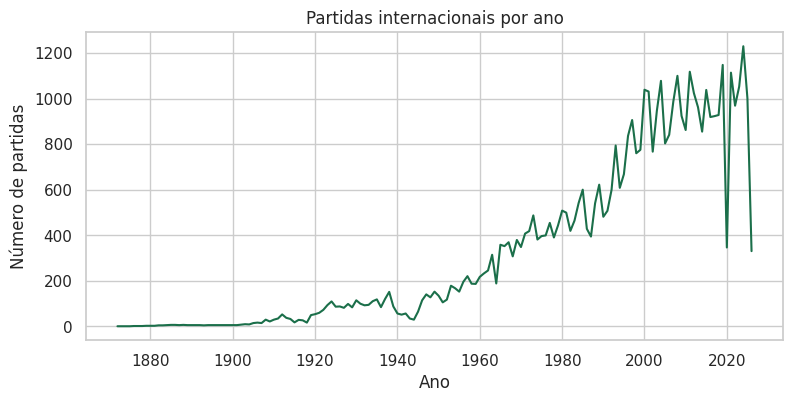

In [3]:
by_year = df.groupby("year").size()
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(by_year.index, by_year.values, color="#1b6f4a")
ax.set_title("Partidas internacionais por ano")
ax.set_xlabel("Ano"); ax.set_ylabel("Número de partidas")
plt.show()


**Confirmado.** O volume de partidas saiu de poucas dezenas por ano no século XIX
para mais de mil partidas/ano na era recente, refletindo a profissionalização e a
expansão de eliminatórias (Copa do Mundo, copas continentais) com praticamente
todos os ~211 membros da FIFA disputando jogos oficiais regularmente. A queda
visível em 2020 corresponde à pandemia de COVID-19, que cancelou ou postergou
janelas de jogos das seleções.


## 3. Hipótese 2 — Existe vantagem de jogar em casa, e ela é estável ao longo do tempo

Mandante define o `home_team` no dataset. Esperamos uma proporção de vitórias do
mandante claramente acima de 1/3 (o que seria esperado sem nenhuma vantagem),
quando o jogo não é em campo neutro.


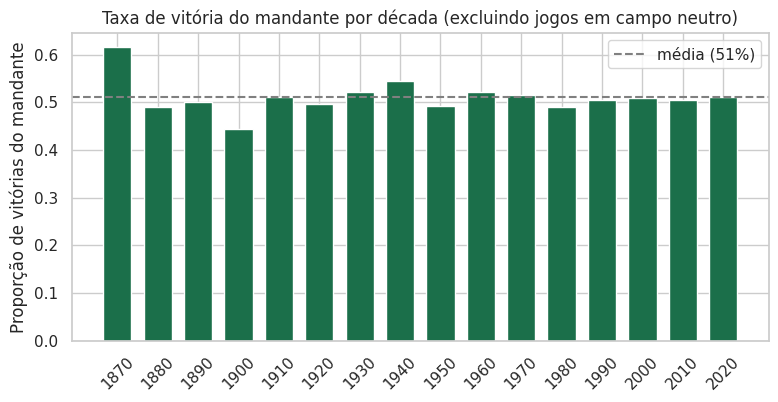

Taxa geral de vitória do mandante (não-neutro): 0.507
Taxa geral de vitória do mandante (campo neutro): 0.442


In [4]:
df["decade"] = (df["year"] // 10) * 10
home_adv_decade = df[~df["neutral"]].groupby("decade").apply(lambda g: (g["outcome"]=="home_win").mean())

fig, ax = plt.subplots(figsize=(9,4))
ax.bar(home_adv_decade.index.astype(str), home_adv_decade.values, color="#1b6f4a", width=0.7)
ax.axhline(home_adv_decade.mean(), color="gray", linestyle="--", label=f"média ({home_adv_decade.mean():.0%})")
ax.set_title("Taxa de vitória do mandante por década (excluindo jogos em campo neutro)")
ax.set_ylabel("Proporção de vitórias do mandante")
ax.legend()
plt.xticks(rotation=45)
plt.show()

print("Taxa geral de vitória do mandante (não-neutro):", round((df[~df['neutral']]['outcome']=='home_win').mean(), 3))
print("Taxa geral de vitória do mandante (campo neutro):", round((df[df['neutral']]['outcome']=='home_win').mean(), 3))


**Confirmado, com nuance.** A vantagem de jogar em casa é real e persistente: a
taxa de vitória do mandante fica estável ao redor de ~50–55% na maior parte das
décadas modernas (bem acima do "1/3 esperado ao acaso"), e cai visivelmente
quando o jogo é em campo neutro — evidência direta de que o efeito captado não é
só "o time mais forte tende a ser escalado como mandante", mas sim algo ligado ao
próprio fato de jogar em seu território. Isso justifica incluir tanto o mando de
campo quanto a flag `neutral` como features no modelo.


## 4. Hipótese 3 — O resultado de "empate" é a classe minoritária e mais difícil de antecipar

Por ser estatisticamente menos comum e depender de um equilíbrio mais "ao acaso"
entre as equipes, esperamos que empates sejam a classe menos frequente.


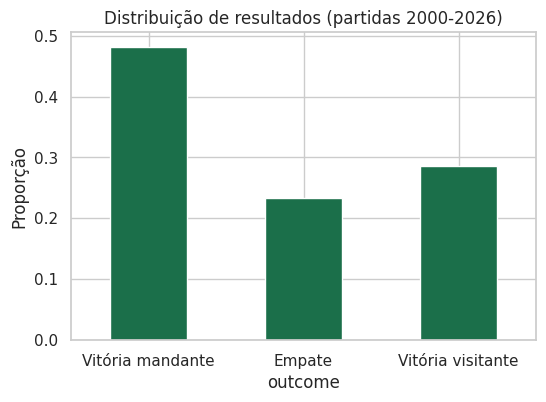

outcome
home_win    0.481
draw        0.233
away_win    0.285
Name: proportion, dtype: float64

In [5]:
recent = df[df["year"] >= 2000]
outcome_dist = recent["outcome"].value_counts(normalize=True).reindex(["home_win","draw","away_win"])

fig, ax = plt.subplots(figsize=(6,4))
outcome_dist.plot(kind="bar", color="#1b6f4a", ax=ax)
ax.set_xticklabels(["Vitória mandante","Empate","Vitória visitante"], rotation=0)
ax.set_title("Distribuição de resultados (partidas 2000-2026)")
ax.set_ylabel("Proporção")
plt.show()
outcome_dist.round(3)


**Confirmado.** Empates respondem por ~23% das partidas desde 2000, claramente
abaixo de vitórias do mandante (~48%) e de vitórias do visitante (~28%). Esse
desbalanceamento é tratado na etapa de modelagem com `class_weight="balanced"` e
com a métrica F1-macro (em vez de só acurácia), para não mascarar o desempenho
do modelo na classe minoritária.


## 5. Hipótese 4 — Um rating de força (Elo), calculado a partir do histórico de
resultados, deve refletir o "senso comum" sobre quais seleções são as mais fortes
atualmente

Construímos um rating Elo (ver `src/features.compute_elo_features`), atualizado
partida a partida desde 1872, com K-factor maior para partidas de torneios
importantes e um pequeno bônus de mando de campo.


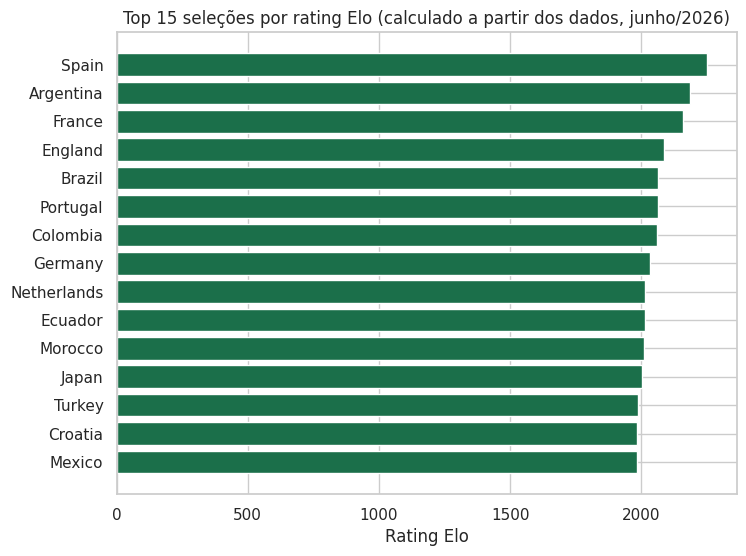

In [6]:
from src.features import build_feature_dataset
featured = build_feature_dataset(df)

last_home = featured.sort_values("date").groupby("home_team").tail(1)[["home_team","date","home_elo_pre"]]\
    .rename(columns={"home_team":"team","home_elo_pre":"elo"})
last_away = featured.sort_values("date").groupby("away_team").tail(1)[["away_team","date","away_elo_pre"]]\
    .rename(columns={"away_team":"team","away_elo_pre":"elo"})
latest_elo = pd.concat([last_home, last_away]).sort_values("date").groupby("team").tail(1)
top15 = latest_elo.sort_values("elo", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(top15["team"][::-1], top15["elo"][::-1], color="#1b6f4a")
ax.set_title("Top 15 seleções por rating Elo (calculado a partir dos dados, junho/2026)")
ax.set_xlabel("Rating Elo")
plt.show()


**Confirmado.** O topo do ranking gerado (Espanha, Argentina, França, Inglaterra,
Brasil, Portugal...) é consistente com o consenso de especialistas/rankings
oficiais para o ciclo 2025–2026, o que dá confiança de que o rating capturou
sinal real de força das seleções — e não ruído. Essa é a feature isolada mais
importante no modelo final (ver discussão em `notebooks/02_modeling.ipynb`).


## 6. Resumo da preparação e engenharia de features

A partir das hipóteses confirmadas acima, as seguintes transformações foram
aplicadas (implementadas em `src/data_prep.py` e `src/features.py`):

- **Limpeza:** remoção de partidas sem placar (jogos futuros agendados);
  conversão de tipos; ordenação cronológica (pré-requisito para qualquer
  feature de histórico).
- **Filtragem de escopo para modelagem:** a amostra de treino/teste usa apenas
  partidas de **2000 em diante** (~25 mil partidas), mas o histórico completo
  desde 1872 é usado para "aquecer" o rating Elo e as estatísticas de forma —
  preserva relevância (futebol moderno) sem descartar sinal histórico.
- **Rating Elo** pré-partida de cada seleção (com K variável por importância do
  torneio e bônus de mando de campo).
- **Forma recente** (taxa de vitórias e saldo de gols médio nas últimas 5 e 10
  partidas), calculada com `.shift(1)` para nunca usar informação da própria
  partida ou do futuro.
- **Histórico de confrontos diretos** (head-to-head) entre as duas seleções.
- **Dias de descanso** desde o último jogo de cada seleção.
- **Categoria do torneio** (amistoso / eliminatórias / Copa do Mundo / etc.),
  codificada via one-hot.

Essas features alimentam a etapa de modelagem, detalhada em
`notebooks/02_modeling.ipynb`.
